### 3.3 – Process Model Creation and Validation

Four-step data preparation pipeline, process discovery (Heuristics Miner → Inductive Miner), quality metrics, pipeline quality chart, and decision mining at XOR gateways.

In [3]:
import pandas as pd
import numpy as np
import pm4py
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.preprocessing import LabelEncoder
from collections import defaultdict
from pm4py.algo.conformance.tokenreplay import algorithm as tbr
from pm4py.algo.evaluation.replay_fitness import algorithm as fitness_eval
import warnings, os
warnings.filterwarnings("ignore")

os.makedirs("../outputs", exist_ok=True)

raw = pm4py.read_xes("../BPI.xes")
raw["time:timestamp"] = pd.to_datetime(raw["time:timestamp"], utc=True)
print(f"Raw log: {raw['case:concept:name'].nunique():,} cases, {len(raw):,} events")

Raw log: 31,509 cases, 1,202,267 events


In [27]:
# Step 1: Lifecycle filter
# Keep only lifecycle:transition == 'complete'.
log = raw[raw["lifecycle:transition"] == "complete"].copy()
print(f"Step 1 - complete events only:")
print(f"  Events: {len(log):,}  (removed {len(raw)-len(log):,})")
print(f"  Cases:  {log['case:concept:name'].nunique():,}")

Step 1 - complete events only:
  Events: 475,306  (removed 726,961)
  Cases:  31,509


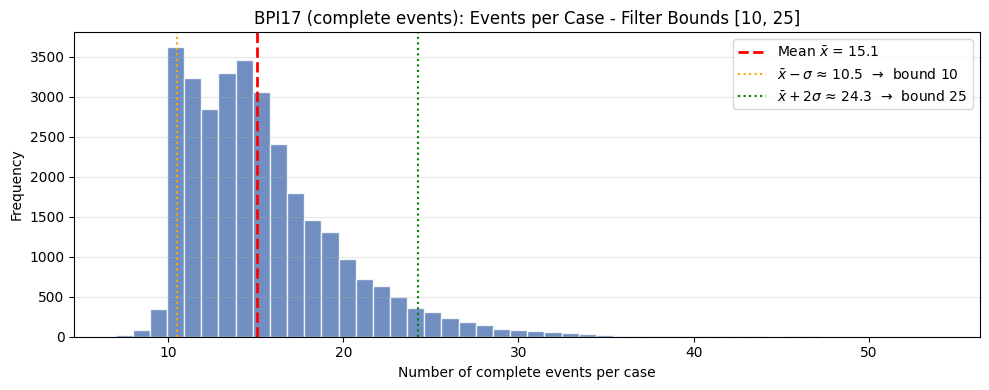

mean=15.08, std=4.60, mean-σ=10.49, mean+2σ=24.28

Step 2 - case-length filter [10-25]:
  Events: 439,832
  Cases:  29,993  (95.2% of original)


In [28]:
# Step 2: Case-length filter
MIN_EVENTS, MAX_EVENTS = 10, 25
case_lengths = log.groupby("case:concept:name")["concept:name"].count()
mean_l = case_lengths.mean()
std_l  = case_lengths.std()

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(case_lengths, bins=48, color="#4C72B0", alpha=0.8, edgecolor="white")
ax.axvline(mean_l,           color="red",    ls="--", lw=2,   label=f"Mean $\\bar{{x}}$ = {mean_l:.1f}")
ax.axvline(mean_l - std_l,   color="orange", ls=":",  lw=1.5, label=f"$\\bar{{x}}-\\sigma$ ≈ {mean_l-std_l:.1f}  →  bound {MIN_EVENTS}")
ax.axvline(mean_l + 2*std_l, color="green",  ls=":",  lw=1.5, label=f"$\\bar{{x}}+2\\sigma$ ≈ {mean_l+2*std_l:.1f}  →  bound {MAX_EVENTS}")
ax.set_title(f"BPI17 (complete events): Events per Case - Filter Bounds [{MIN_EVENTS}, {MAX_EVENTS}]")
ax.set_xlabel("Number of complete events per case"); ax.set_ylabel("Frequency")
ax.legend(); ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("../outputs/caselength_histogram.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"mean={mean_l:.2f}, std={std_l:.2f}, mean-σ={mean_l-std_l:.2f}, mean+2σ={mean_l+2*std_l:.2f}")

# Apply filter
valid = case_lengths[(case_lengths >= MIN_EVENTS) & (case_lengths <= MAX_EVENTS)].index
log = log[log["case:concept:name"].isin(valid)].copy()
print(f"\nStep 2 - case-length filter [{MIN_EVENTS}-{MAX_EVENTS}]:")
print(f"  Events: {len(log):,}")
print(f"  Cases:  {log['case:concept:name'].nunique():,}  "
      f"({log['case:concept:name'].nunique()/raw['case:concept:name'].nunique()*100:.1f}% of original)")

Discovering spaghetti model (all activities)...
  Spaghetti: 83 nodes, 106 arcs, saved spaghetti_model.png


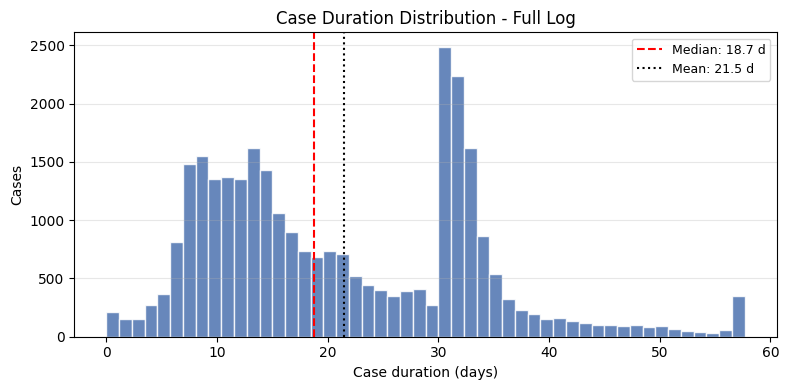


Step 3 - A_-only:
  Events:   224,943
  Cases:    29,993
  Variants: 88
  Mean case duration (A_-only): 21.4 d  (full-activity: 21.5 d)


In [29]:
# ── Step 3: A_-only activities ────────────────────────────────────────────────

# 3a. Spaghetti model (complete events, all activities) - save for report
print("Discovering spaghetti model (all activities)...")
net_all, im_all, fm_all = pm4py.discover_petri_net_inductive(log, noise_threshold=0.2)
pm4py.save_vis_petri_net(net_all, im_all, fm_all, "../outputs/spaghetti_model.png")
print(f"  Spaghetti: {len(net_all.places)+len(net_all.transitions)} nodes, "
      f"{len(net_all.arcs)} arcs, saved spaghetti_model.png")

# 3b. Case duration: full log only
g        = log.groupby("case:concept:name")["time:timestamp"]
dur_full = (g.max() - g.min()).dt.total_seconds().div(86400)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(dur_full.clip(upper=dur_full.quantile(0.99)), bins=50,
        color="#4C72B0", alpha=0.85, edgecolor="white")
ax.axvline(dur_full.median(), color="red",   ls="--", lw=1.5,
           label=f"Median: {dur_full.median():.1f} d")
ax.axvline(dur_full.mean(),   color="black", ls=":",  lw=1.5,
           label=f"Mean: {dur_full.mean():.1f} d")
ax.set_title("Case Duration Distribution - Full Log")
ax.set_xlabel("Case duration (days)")
ax.set_ylabel("Cases")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("../outputs/duration_histogram.png", dpi=130, bbox_inches="tight")
plt.show()

# Preserve the full-activity log before restricting to A_ only.
# Required for full-log model quality metrics (Table 3) and appendix figures.
log_pre_a = log.copy()

# Apply A_-only filter
log_a = log[log["concept:name"].str.startswith("A_")].copy()
log   = log_a
print(f"\nStep 3 - A_-only:")
print(f"  Events:   {len(log):,}")
print(f"  Cases:    {log['case:concept:name'].nunique():,}")
print(f"  Variants: {log.groupby('case:concept:name')['concept:name'].apply(tuple).nunique()}")

# Case duration on A_-only log (report: 21.5 d, vs 21.4 d full-activity above)
dur_a = (log.groupby("case:concept:name")["time:timestamp"]
            .agg(lambda x: (x.max() - x.min()).total_seconds() / 86400))
print(f"  Mean case duration (A_-only): {dur_a.mean():.1f} d  "
      f"(full-activity: {dur_full.mean():.1f} d)")

In [30]:
# ── Full-Log Discovery (all activities, for appendix) ─────────────────────────
# Applies both Heuristics Miner and Inductive Miner to log_pre_a —
# the lifecycle+case-length-filtered log before the A_-only restriction.
# Results are saved for the appendix only; too complex for direct analysis.

print("Discovering full-log models (all W_, O_, A_ activities)...")

# Inductive Miner — already computed as net_all above; re-save under explicit name
pm4py.save_vis_petri_net(net_all, im_all, fm_all, "../outputs/full_log_inductive.png")
print(f"  Inductive: {len(net_all.places)+len(net_all.transitions)} nodes  ->  full_log_inductive.png")

# Heuristics Miner on full log (log_pre_a: all activities, pre A_-only filter)
net_all_h, im_all_h, fm_all_h = pm4py.discover_petri_net_heuristics(
    log_pre_a, dependency_threshold=0.5, and_threshold=0.65)
pm4py.save_vis_petri_net(net_all_h, im_all_h, fm_all_h, "../outputs/full_log_heuristics.png")
print(f"  Heuristics: {len(net_all_h.places)+len(net_all_h.transitions)} nodes  ->  full_log_heuristics.png")

Discovering full-log models (all W_, O_, A_ activities)...
  Inductive: 83 nodes  ->  full_log_inductive.png
  Heuristics: 141 nodes  ->  full_log_heuristics.png


In [31]:
# ── Full-Log Inductive Miner Quality Metrics (Table 3 in report) ──────────────
# Computed on log_pre_a: lifecycle+case-length-filtered log, all activities.
print("Full-log Inductive Miner quality metrics (Table 3) ...")

fitness_all    = pm4py.fitness_token_based_replay(log_pre_a, net_all, im_all, fm_all)["log_fitness"]
precision_all  = pm4py.precision_token_based_replay(log_pre_a, net_all, im_all, fm_all)
gen_all        = pm4py.generalization_tbr(log_pre_a, net_all, im_all, fm_all)
n_nodes_all    = len(net_all.places) + len(net_all.transitions)

print(f"  Fitness:        {fitness_all:.4f}")   # report: 0.9928
print(f"  Precision:      {precision_all:.4f}") # report: 0.3326
print(f"  Generalization: {gen_all:.4f}")        # report: 0.9785
print(f"  Nodes:          {n_nodes_all}")        # report: 83

Full-log Inductive Miner quality metrics (Table 3) ...


replaying log with TBR, completed traces :: 100%|██████████| 4549/4549 [00:05<00:00, 878.61it/s]


  Fitness:        0.9928
  Precision:      0.3326
  Generalization: 0.9785
  Nodes:          83


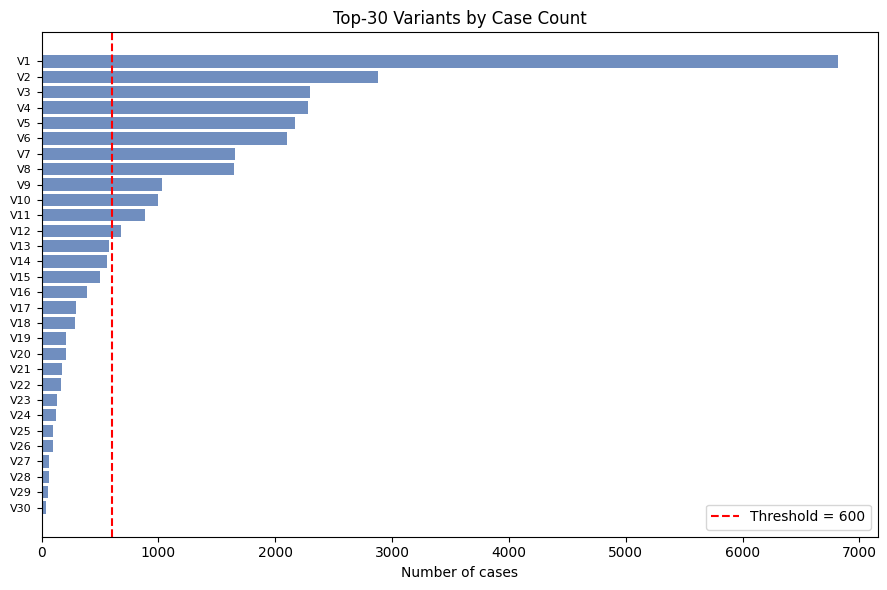

Step 4 - rare-variant filter (>=600 cases per variant):
  Events:   183,318
  Cases:    25,444  (80.8% of original)
  Variants: 12
Saved: BPI17_cleaned_frequent_variants_only.xes


In [32]:
# Step 4: Rare-variant filter 
var_series = (log.sort_values("time:timestamp")
                 .groupby("case:concept:name")["concept:name"]
                 .apply(tuple))
freq = var_series.value_counts()

# Variant histogram - top-30 only
top30 = freq.head(30)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(range(len(top30)), top30.values[::-1], color="#4C72B0", alpha=0.8)
ax.axvline(600, color="red", ls="--", lw=1.5, label="Threshold = 600")
ax.set_yticks(range(len(top30)))
ax.set_yticklabels([f"V{len(top30)-i}" for i in range(len(top30))], fontsize=8)
ax.set_title("Top-30 Variants by Case Count"); ax.set_xlabel("Number of cases")
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/variant_histogram.png", dpi=130, bbox_inches="tight")
plt.show()

# Apply filter
MIN_CASES     = 600
keep_variants = set(freq[freq >= MIN_CASES].index)
keep_cases    = var_series[var_series.isin(keep_variants)].index
log           = log[log["case:concept:name"].isin(keep_cases)].copy()
total_original = raw["case:concept:name"].nunique()
print(f"Step 4 - rare-variant filter (>={MIN_CASES} cases per variant):")
print(f"  Events:   {len(log):,}")
print(f"  Cases:    {log['case:concept:name'].nunique():,}  "
      f"({log['case:concept:name'].nunique()/total_original*100:.1f}% of original)")
print(f"  Variants: {log.groupby('case:concept:name')['concept:name'].apply(tuple).nunique()}")

pm4py.write_xes(log, "../BPI17_cleaned_frequent_variants_only.xes",
                case_id_key="case:concept:name", timestamp_key="time:timestamp")
print("Saved: BPI17_cleaned_frequent_variants_only.xes")

In [33]:
# ── First Attempt: Heuristics Miner ──────────────────────────────────────────
# Grid search over dependency / AND thresholds on the cleaned log.
log_disc = pm4py.read_xes("../BPI17_cleaned_frequent_variants_only.xes")
cases    = log_disc["case:concept:name"].unique()
sample   = np.random.default_rng(42).choice(cases, size=min(1000, len(cases)), replace=False)
df_s     = log_disc[log_disc["case:concept:name"].isin(sample)]

dep_vals = [0.5, 0.6, 0.7, 0.8, 0.9]
and_vals = [0.50, 0.60, 0.65, 0.70, 0.75, 0.80]
rows     = []

for dep in dep_vals:
    for and_ in and_vals:
        net, im, fm = pm4py.discover_petri_net_heuristics(
            log_disc, dependency_threshold=dep, and_threshold=and_)
        try:
            fit  = fitness_eval.apply(df_s, net, im, fm)["log_fitness"]
            prec = pm4py.precision_token_based_replay(df_s, net, im, fm)
        except Exception:
            fit = prec = 0.0
        f = 2*fit*prec/(fit+prec) if (fit+prec) > 0 else 0
        rows.append(dict(dep=dep, and_=and_, fitness=fit, precision=prec, f_score=f))

results_h = pd.DataFrame(rows).sort_values("f_score", ascending=False)
best      = results_h.iloc[0]
print(f"Best: dep={best.dep}, and={best.and_}  "
      f"fitness={best.fitness:.3f}, precision={best.precision:.3f}, F={best.f_score:.3f}")
print(results_h.head(10).to_string(index=False))

# Save best-config model figure
net_h, im_h, fm_h = pm4py.discover_petri_net_heuristics(
    log_disc, dependency_threshold=0.5, and_threshold=0.65)
pm4py.save_vis_petri_net(net_h, im_h, fm_h, "../outputs/heuristics_model.png")
print("Saved: heuristics_model.png")

replaying log with TBR, completed traces :: 100%|██████████| 18/18 [00:00<00:00, 7344.11it/s]


Best: dep=0.5, and=0.5  fitness=0.878, precision=0.960, F=0.917
 dep  and_  fitness  precision  f_score
 0.5  0.50 0.877531   0.959744 0.916798
 0.9  0.60 0.877531   0.959744 0.916798
 0.8  0.50 0.877531   0.959744 0.916798
 0.5  0.60 0.877531   0.959744 0.916798
 0.7  0.65 0.877531   0.959744 0.916798
 0.7  0.60 0.877531   0.959744 0.916798
 0.7  0.50 0.877531   0.959744 0.916798
 0.8  0.65 0.877531   0.959744 0.916798
 0.9  0.50 0.877531   0.959744 0.916798
 0.6  0.65 0.877531   0.959744 0.916798
Saved: heuristics_model.png


In [34]:
# ── Heuristics Miner Quality Metrics (Table 2 in report) ─────────────────────
# Computed on log_disc: the full rare-variant-filtered A_-only log.
# The grid search above uses a 1000-case sample for speed; these are the
# official metrics on the full filtered log that appear in the report.
print("Heuristics Miner quality metrics on full filtered log (Table 2) ...")

fitness_h    = pm4py.fitness_token_based_replay(log_disc, net_h, im_h, fm_h)["log_fitness"]
precision_h  = pm4py.precision_token_based_replay(log_disc, net_h, im_h, fm_h)
gen_h        = pm4py.generalization_tbr(log_disc, net_h, im_h, fm_h)
n_nodes_h    = len(net_h.places) + len(net_h.transitions)

print(f"  Fitness:        {fitness_h:.4f}")   # report: 0.9444
print(f"  Precision:      {precision_h:.4f}") # report: 0.9581
print(f"  Generalization: {gen_h:.4f}")        # report: 0.9903
print(f"  Nodes:          {n_nodes_h}")        # report: 23

Heuristics Miner quality metrics on full filtered log (Table 2) ...


replaying log with TBR, completed traces :: 100%|██████████| 12/12 [00:00<00:00, 78.05it/s]


  Fitness:        0.9427
  Precision:      0.9614
  Generalization: 0.9909
  Nodes:          23


In [35]:
# ── Final Model: Inductive Miner ──────────────────────────────────────────────
import re
from pm4py.visualization.petri_net import visualizer as pn_viz
from pm4py.visualization.bpmn    import visualizer as bpmn_viz

# log_disc was already loaded in the Heuristics Miner cell
log_final = log_disc

print("Discovering final process model (Inductive Miner, noise_threshold=0.2)...")
net_final, im_final, fm_final = pm4py.discover_petri_net_inductive(log_final, noise_threshold=0.2)
bpmn_final = pm4py.discover_bpmn_inductive(log_final, noise_threshold=0.2)

# ── Highlight p_3 and p_11 in Petri net ──────────────────────────────────────
place_gv_id = {p.name: str(id(p)) for p in net_final.places}

def highlight_petri(gviz, ids_labels):
    new_body = []
    for line in gviz.body:
        replaced = False
        for gv_id, label in ids_labels.items():
            if line.strip().startswith(gv_id + " ") and "shape=circle" in line:
                new_body.append(
                    f'\t{gv_id} [label="{label}" fillcolor="#E74C3C" fixedsize=true '
                    f'fontcolor=white fontsize=13 fontweight=bold shape=circle style=filled width=1.1]')
                replaced = True; break
        if not replaced: new_body.append(line)
    gviz.body = new_body

def highlight_bpmn(gviz, ids_labels):
    new_body = []
    for line in gviz.body:
        replaced = False
        for gv_id, label in ids_labels.items():
            if line.strip().startswith(gv_id + " ") and "shape=diamond" in line:
                new_body.append(
                    f'\t{gv_id} [label="{label}" fillcolor="#E74C3C" fontcolor=white '
                    f'fontsize=13 fontweight=bold shape=diamond style=filled]')
                replaced = True; break
        if not replaced: new_body.append(line)
    gviz.body = new_body

gviz_pn = pn_viz.apply(net_final, im_final, fm_final, parameters={"format": "png"})
highlight_petri(gviz_pn, {place_gv_id["p_3"]: "p_3", place_gv_id["p_11"]: "p_11"})
pn_viz.save(gviz_pn, "../outputs/final_petri_net.png")

# ── Highlight p_3 and p_11 in BPMN ───────────────────────────────────────────
gviz_bpmn = bpmn_viz.apply(bpmn_final, parameters={"format": "png"})
src = gviz_bpmn.source

m = re.search(r'(\d+) \[label="A_Create Application"', src)
if m:
    create_id = m.group(1)
    m2 = re.search(rf'{create_id} -> (\d+)', src)
    if m2: highlight_bpmn(gviz_bpmn, {m2.group(1): "p_3"})

m = re.search(r'(\d+) \[label=A_Validating', src)
if m:
    val_id = m.group(1)
    m2 = re.search(rf'{val_id} -> (\d+)', src)
    if m2: highlight_bpmn(gviz_bpmn, {m2.group(1): "p_11"})

bpmn_viz.save(gviz_bpmn, "../outputs/final_bpmn_model.png")

print(f"Model: {len(net_final.places)+len(net_final.transitions)} nodes")
print("Saved: final_bpmn_model.png (p_3, p_11 highlighted), final_petri_net.png (p_3, p_11 highlighted)")

Discovering final process model (Inductive Miner, noise_threshold=0.2)...
Model: 26 nodes
Saved: final_bpmn_model.png (p_3, p_11 highlighted), final_petri_net.png (p_3, p_11 highlighted)


In [36]:
# ── Quality Metrics (Token-Based Replay) ─────────────────────────────────────
print("Computing quality metrics ...")

fitness_result = pm4py.fitness_token_based_replay(log_final, net_final, im_final, fm_final)
fitness        = fitness_result.get("log_fitness", 0.0)
precision      = pm4py.precision_token_based_replay(log_final, net_final, im_final, fm_final)
generalization = pm4py.generalization_tbr(log_final, net_final, im_final, fm_final)

n_nodes  = len(net_final.places) + len(net_final.transitions)
avg_deg  = len(net_final.arcs) / n_nodes if n_nodes > 0 else 0
xor_splits = sum(
    1 for p in net_final.places
    if len([a for a in net_final.arcs if a.source == p]) > 1
)

print(f"\n{'='*50}")
print(f"  Final Process Model - Quality Report")
print(f"{'='*50}")
print(f"  Fitness (TBR):            {fitness:.4f}")
print(f"  Precision (TBR):          {precision:.4f}")
print(f"  Generalization (TBR):     {generalization:.4f}")
print(f"  Model Size (nodes):       {n_nodes}")
print(f"  Avg Node Degree:          {avg_deg:.4f}")
print(f"  XOR Split Gateways:       {xor_splits}")
print(f"{'='*50}")

Computing quality metrics ...


replaying log with TBR, completed traces :: 100%|██████████| 12/12 [00:00<00:00, 47.33it/s]


  Final Process Model - Quality Report
  Fitness (TBR):            1.0000
  Precision (TBR):          0.8328
  Generalization (TBR):     0.9909
  Model Size (nodes):       26
  Avg Node Degree:          1.1538
  XOR Split Gateways:       5


In [37]:
# ── Structural Appropriateness (Rozinat 2010) ─────────────────────────────────
# Implemented from scratch per:
#   Rozinat, A. (2010). Process mining: conformance and extension.
#   PhD thesis, Eindhoven University of Technology.
#
# Simple Structural Appropriateness (SSA):
#   SSA = (|A_L| + 2) / (|P_N| + |T_N|)
#
# Advanced Structural Appropriateness (ASA):
#   ASA = SSA * (|T_vis_unique| / |T_vis|)
#
# A_L          : distinct visible transition labels in the log
# P_N          : number of places
# T_N          : total transitions (visible + silent)
# T_vis        : visible (non-silent) transitions
# T_vis_unique : distinct visible labels (= A_L)

from collections import Counter

def compute_ssa_asa(net):
    P_N    = len(net.places)
    T_N    = len(net.transitions)
    visible = [t for t in net.transitions if t.label is not None]
    T_vis   = len(visible)
    label_counts = Counter(t.label for t in visible)
    A_L          = len(label_counts)   # distinct activity labels
    T_vis_unique = A_L                 # one representative per distinct label
    ssa = (A_L + 2) / (P_N + T_N) if (P_N + T_N) > 0 else 0.0
    asa = ssa * (T_vis_unique / T_vis) if T_vis > 0 else 0.0
    return dict(P=P_N, T=T_N, T_vis=T_vis, A_L=A_L, SSA=ssa, ASA=asa)

model_configs = {
    "Spaghetti (Inductive, all activities)": net_all,
    "Heuristics Miner (dep=0.5, and=0.65)":  net_h,
    "Final (Inductive, A_ only, noise=0.2)":  net_final,
}

print(f"{'Model':<42} {'P':>4} {'T':>4} {'T_vis':>6} {'A_L':>5} {'SSA':>7} {'ASA':>7}")
print("-" * 78)
for name, net in model_configs.items():
    r = compute_ssa_asa(net)
    print(f"{name:<42} {r['P']:>4} {r['T']:>4} {r['T_vis']:>6} {r['A_L']:>5} {r['SSA']:>7.4f} {r['ASA']:>7.4f}")

Model                                         P    T  T_vis   A_L     SSA     ASA
------------------------------------------------------------------------------
Spaghetti (Inductive, all activities)        32   51     24    24  0.3133  0.3133
Heuristics Miner (dep=0.5, and=0.65)         11   12     10    10  0.5217  0.5217
Final (Inductive, A_ only, noise=0.2)        11   15     10    10  0.4615  0.4615


In [ ]:
# ── Decision Mining (de Leoni & van der Aalst, SAC 2013) ─────────────────────
# Inspired by the official pm4py alignment-based decision tree example:
# https://github.com/process-intelligence-solutions/pm4py/blob/release/examples/decisiontree_align_example.py

from pm4py.algo.decision_mining import algorithm as dm_algo

log_el = pm4py.convert_to_event_log(log_final)

# Identify XOR split places
xor_places = {
    p for p in net_final.places
    if len([a for a in net_final.arcs if a.source == p]) > 1
}
print(f"XOR split gateways: {len(xor_places)}")

le_app  = LabelEncoder()
le_goal = LabelEncoder()
_attrs = log_final.groupby("case:concept:name").agg(
    ApplicationType=("case:ApplicationType", "first"),
    LoanGoal=("case:LoanGoal", "first"),
)
le_app.fit(_attrs["ApplicationType"].fillna("Unknown"))
le_goal.fit(_attrs["LoanGoal"].fillna("Unknown"))

# Train one decision tree per XOR gateway using pm4py's built-in function
decision_blocks = {}
for place in sorted(xor_places, key=lambda p: p.name):
    pname = place.name
    try:
        clf, feature_names, classes = dm_algo.get_decision_tree(
            log_el, net_final, im_final, fm_final, decision_point=pname)
    except Exception as e:
        print(f"  Skipping '{pname}': {e}")
        continue
    if clf is None or len(set(classes)) < 2:
        print(f"  Skipping '{pname}' - degenerate (single class)")
        continue
    decision_blocks[pname] = dict(clf=clf, classes=list(classes),
                                   feature_names=list(feature_names))
    print(f"-- XOR '{pname}':  classes={list(classes)}  features={list(feature_names)}")

print(f"\nInformative decision blocks: {len(decision_blocks)} / {len(xor_places)} XOR places")

NameError: name 'xor_places' is not defined

In [ ]:
# Decision Mining Visualization 
from matplotlib.patches import FancyBboxPatch

def draw_clean_tree(ax, clf, class_names, le_app, le_goal, max_depth=2):
    tree_ = clf.tree_
    feat_names = ["ApplicationType", "RequestedAmount", "LoanGoal"]
    level_y = {0: 0.88, 1: 0.56, 2: 0.16}
    box_w, box_h = 0.22, 0.13
    palette = ["#AED6F1", "#A9DFBF", "#FAD7A0", "#F1948A", "#D7BDE2"]

    def majority_class(nid):
        return int(np.argmax(tree_.value[nid]))

    def condition_text(nid):
        fi, th = tree_.feature[nid], tree_.threshold[nid]
        if feat_names[fi] == "ApplicationType":
            return "Application\nType?"
        elif feat_names[fi] == "RequestedAmount":
            return f"Amount\n≤ €{th:,.0f}?"
        else:
            return f"Loan Goal\n≤ {th:.1f}?"

    def branch_labels(nid):
        fi, th = tree_.feature[nid], tree_.threshold[nid]
        if feat_names[fi] == "ApplicationType":
            return le_app.classes_[0], le_app.classes_[1]
        elif feat_names[fi] == "RequestedAmount":
            return f"≤ €{th:,.0f}", f"> €{th:,.0f}"
        else:
            return f"≤ {th:.1f}", f"> {th:.1f}"

    def leaf_text(nid):
        cls = class_names[majority_class(nid)]
        return "Skip" if cls == "[tau]" else cls

    node_info = {}
    def assign(nid, x0, x1, depth):
        if depth > max_depth: return
        node_info[nid] = ((x0+x1)/2, level_y[depth], depth)
        if tree_.children_left[nid] != -1:
            mid = (x0+x1)/2
            assign(tree_.children_left[nid],  x0, mid, depth+1)
            assign(tree_.children_right[nid], mid, x1,  depth+1)
    assign(0, 0.0, 1.0, 0)

    for nid, (xp, yp, dp) in node_info.items():
        if dp >= max_depth or tree_.children_left[nid] == -1: continue
        true_lbl, false_lbl = branch_labels(nid)
        for child_id, lbl, left in [
            (tree_.children_left[nid],  true_lbl,  True),
            (tree_.children_right[nid], false_lbl, False)
        ]:
            if child_id not in node_info: continue
            xc, yc, _ = node_info[child_id]
            ax.annotate("", xy=(xc, yc + box_h/2 + 0.01),
                        xytext=(xp, yp - box_h/2 - 0.01),
                        xycoords="axes fraction", textcoords="axes fraction",
                        arrowprops=dict(arrowstyle="-|>", color="#555", lw=1.8, mutation_scale=14))
            mx = (xp+xc)/2 + (-0.06 if left else 0.06)
            my = (yp+yc)/2
            ax.text(mx, my, lbl, transform=ax.transAxes,
                    ha="center", va="center", fontsize=10.5, color="#333",
                    fontstyle="italic",
                    bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.9, ec="none"))

    for nid, (x, y, depth) in node_info.items():
        is_leaf = (tree_.children_left[nid] == -1) or (depth >= max_depth)
        if is_leaf:
            mc = majority_class(nid)
            fc, ec = palette[mc % len(palette)], "#1A5276"
            text, fw = leaf_text(nid), "bold"
        else:
            fc, ec = "#EBF5FB", "#2471A3"
            text, fw = condition_text(nid), "normal"

        ax.add_patch(FancyBboxPatch(
            (x - box_w/2, y - box_h/2), box_w, box_h,
            boxstyle="round,pad=0.02", facecolor=fc, edgecolor=ec, lw=2,
            transform=ax.transAxes, clip_on=False, zorder=3))
        ax.text(x, y, text, transform=ax.transAxes,
                ha="center", va="center", fontsize=12, fontweight=fw, zorder=4)

    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis("off")

# Save the two most informative gateways as separate figures
top2 = list(decision_blocks.items())[:2]

for i, (pname, dt) in enumerate(top2, start=1):
    fig, ax = plt.subplots(figsize=(7, 5))
    draw_clean_tree(ax, dt["clf"], dt["classes"], le_app, le_goal, max_depth=2)
    ax.set_title(f"Gateway {pname}", fontsize=12, fontweight="bold", pad=12)
    plt.tight_layout()
    fname = f"../outputs/decision_tree_{i}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fname}  ({pname})")

In [ ]:
from sklearn.metrics import accuracy_score

for place in sorted(xor_places, key=lambda p: p.name):
    if place.name not in decision_blocks:
        continue
    clf = decision_blocks[place.name]["clf"]
    n_traces = clf.tree_.n_node_samples[0]
    # Training accuracy from leaf node majority-class counts
    total_correct = sum(
        clf.tree_.value[i][0].max()
        for i in range(clf.tree_.node_count)
        if clf.tree_.children_left[i] == -1  # leaf node
    )
    acc = total_correct / n_traces
    print(f"{place.name}: n_traces={n_traces:,}, training_accuracy={acc:.4f} ({acc*100:.1f}%)")
    # report: p_3 -> 25,444 traces, 86.0%; p_11 -> 16,460 traces, 64.2%

NameError: name 'pm4py' is not defined